# Day 11 — Classification Machine Learning Task
**Linkific AI/ML Internship**

---

## 1. Day 11 Objective

The objective of Day 11 is to introduce foundational **Classification** concepts in Supervised Machine Learning:
- Understand the fundamental difference between Regression (predicting continuous numerical values) and Classification (predicting discrete category labels).
- Train two standard beginner classification algorithms: **Logistic Regression** and **Decision Tree**.
- Use the standard, clean **Iris dataset** from Scikit-learn (150 samples, 4 features, 3 species classes).
- Apply a single, identical train-test split for a fair side-by-side comparison.
- Evaluate and compare both models using **Accuracy** as the primary evaluation metric.
- Record data-driven observations based on actual model predictions.

## 2. What is Classification?

**Classification** is a form of Supervised Machine Learning where the algorithm learns from labeled historical data to assign new observations to predefined discrete categories (classes).

### Key Contrast: Regression vs. Classification
- **Day 10 Linear Regression:** Predicted a **continuous quantitative number** (e.g., Base Salary = \$67,682.18).
- **Day 11 Classification:** Predicts a **discrete category or class label** (e.g., Iris Flower Species = Setosa, Versicolor, or Virginica).

```text
Input Features (X)                  Trained Classifier                  Predicted Target (y)
[Sepal Length, Sepal Width,   ===>  [Logistic Regression /        ===>  Class Label:
 Petal Length, Petal Width]          Decision Tree]                      'setosa' (0), 'versicolor' (1), or 'virginica' (2)
```

## 3. Classification Workflow

Our beginner classification pipeline follows a rigorous 8-step structure:

1. **Load Dataset:** Ingest the benchmark Iris dataset dynamically via Scikit-learn.
2. **Dataset Overview:** Inspect dimensions, data types, class balances, and verify zero missing values.
3. **Select Features ($X$) and Target ($y$):** Extract flower measurements into a feature matrix and species codes into a target vector.
4. **Train-Test Split:** Partition 80% for training (120 samples) and 20% for testing (30 samples) using stratified sampling.
5. **Train Logistic Regression:** Fit a linear probabilistic decision boundary (`max_iter=200`).
6. **Train Decision Tree:** Fit a rule-based decision tree (`random_state=42`).
7. **Make Predictions & Calculate Accuracy:** Evaluate both models on the identical test set.
8. **Compare & Visualize:** Analyze accuracy differences and visualize results with a clean bar chart.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("Required Scikit-learn and analysis libraries imported successfully.")


Required Scikit-learn and analysis libraries imported successfully.


In [2]:
# Load the standard Iris dataset dynamically from Scikit-learn
iris = load_iris()

# Create a Pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

# Add readable class labels for exploration
species_map = {idx: name for idx, name in enumerate(iris.target_names)}
df["species"] = df["target"].map(species_map)

print(f"Iris dataset loaded: {df.shape[0]} samples, {len(iris.feature_names)} features, {len(iris.target_names)} classes.")


Iris dataset loaded: 150 samples, 4 features, 3 classes.


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values count per column:")
print(df.isnull().sum())
print("\nClass distribution (balanced 50 samples each):")
print(df["species"].value_counts())
print("\nFirst 5 rows:")
df.head(5)


Dataset Shape: 150 rows, 6 columns

Missing values count per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0

Class distribution (balanced 50 samples each):
species
setosa        50
versicolor    50
virginica     50

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


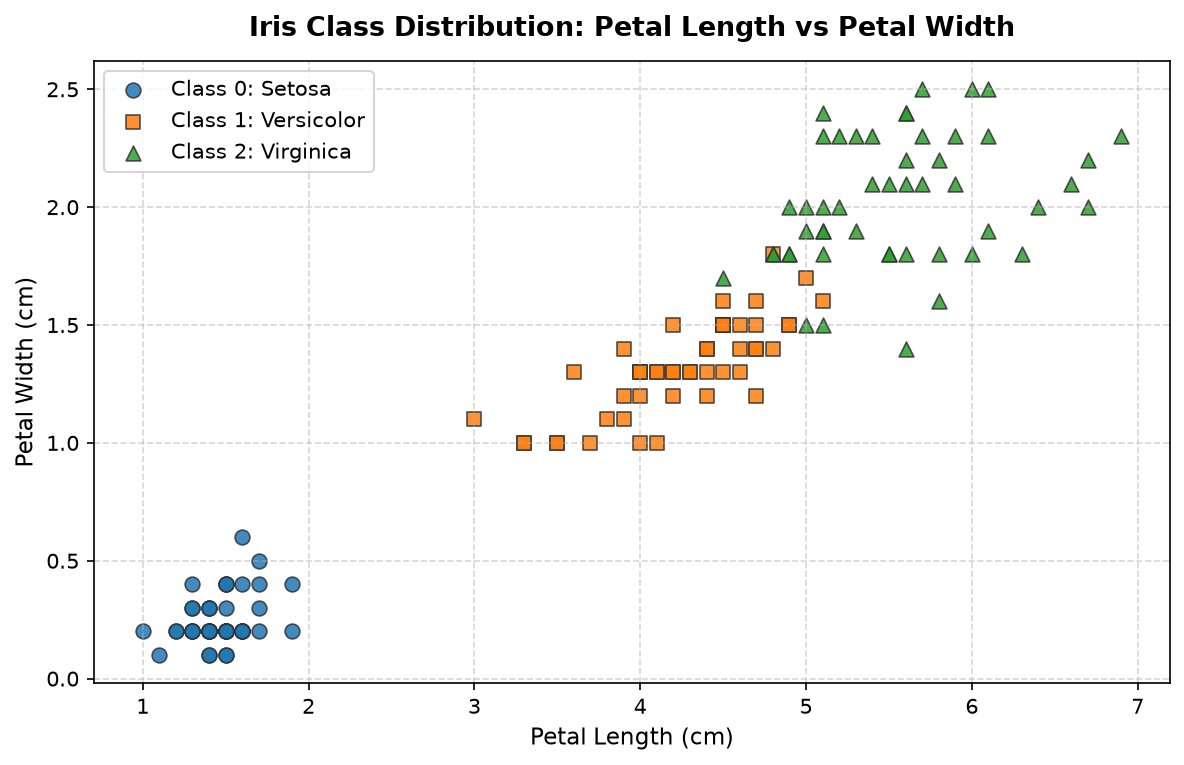

In [4]:
# Visualize the Iris class distribution across petal dimensions
plt.figure(figsize=(8, 5.2), dpi=150)
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]
markers = ["o", "s", "^"]

for idx, target_name in enumerate(iris.target_names):
    subset = df[df["target"] == idx]
    plt.scatter(
        subset["petal length (cm)"], subset["petal width (cm)"],
        label=f"Class {idx}: {target_name.capitalize()}",
        color=palette[idx], marker=markers[idx], s=55, alpha=0.85, edgecolors="#333333", linewidth=0.8
    )

plt.title("Iris Class Distribution: Petal Length vs Petal Width", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Petal Length (cm)", fontsize=11)
plt.ylabel("Petal Width (cm)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


In [5]:
# Isolate input features (X) and target class (y)
X = df[iris.feature_names]
y = df["target"]

print(f"Feature matrix (X) shape: {X.shape} (4 continuous flower measurements)")
print(f"Target vector  (y) shape: {y.shape} (species codes 0, 1, 2)")
print("Features:", list(X.columns))
print("Target classes:", list(iris.target_names))


Feature matrix (X) shape: (150, 4) (4 continuous flower measurements)
Target vector  (y) shape: (150,) (species codes 0, 1, 2)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [6]:
# 80% Training (120 samples), 20% Testing (30 samples)
# stratify=y preserves exact class distribution (10 samples per class in test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} samples (80%)")
print(f"Testing set size:  {len(X_test)} samples (20%)")
print("Test set class distribution:", dict(y_test.value_counts().sort_index()))
print("Note: The identical test split is used for both models to guarantee a fair comparison.")


Training set size: 120 samples (80%)
Testing set size:  30 samples (20%)
Test set class distribution: {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}
Note: The identical test split is used for both models to guarantee a fair comparison.


In [7]:
# Instantiate Logistic Regression model
# max_iter=200 ensures convergence on multi-class data
logistic_model = LogisticRegression(max_iter=200)
print("Logistic Regression model instantiated successfully:")
print(logistic_model)


Logistic Regression model instantiated successfully:
LogisticRegression(max_iter=200)


In [8]:
# Train Logistic Regression model using .fit()
logistic_model.fit(X_train, y_train)
print("Logistic Regression model training completed successfully.")


Logistic Regression model training completed successfully.


In [9]:
# Make predictions on unseen test records using .predict()
logistic_pred = logistic_model.predict(X_test)
print(f"Generated {len(logistic_pred)} predictions with Logistic Regression.")


Generated 30 predictions with Logistic Regression.


In [10]:
# Calculate accuracy dynamically
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_correct = (y_test == logistic_pred).sum()

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f} ({logistic_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {logistic_correct} out of {len(y_test)} test samples.")


Logistic Regression Accuracy: 0.9667 (96.67%)
Correct Predictions: 29 out of 30 test samples.


In [11]:
# Instantiate Decision Tree classifier with random_state=42 for reproducibility
decision_tree = DecisionTreeClassifier(random_state=42)
print("Decision Tree model instantiated successfully:")
print(decision_tree)


Decision Tree model instantiated successfully:
DecisionTreeClassifier(random_state=42)


In [12]:
# Train Decision Tree model using .fit()
decision_tree.fit(X_train, y_train)
print("Decision Tree model training completed successfully.")


Decision Tree model training completed successfully.


In [13]:
# Make predictions on unseen test records using .predict()
tree_pred = decision_tree.predict(X_test)
print(f"Generated {len(tree_pred)} predictions with Decision Tree.")


Generated 30 predictions with Decision Tree.


In [14]:
# Calculate accuracy dynamically
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_correct = (y_test == tree_pred).sum()

print(f"Decision Tree Accuracy:       {tree_accuracy:.4f} ({tree_accuracy * 100:.2f}%)")
print(f"Correct Predictions: {tree_correct} out of {len(y_test)} test samples.")


Decision Tree Accuracy:       0.9333 (93.33%)
Correct Predictions: 28 out of 30 test samples.


In [15]:
# Build dynamic accuracy comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Accuracy (%)": [f"{logistic_accuracy * 100:.2f}%", f"{tree_accuracy * 100:.2f}%"]
})

print("Model Accuracy Comparison Table:")
display(comparison)

# Dynamic Prediction Results Table (First 10 test samples)
species_names = iris.target_names
prediction_results = pd.DataFrame({
    "Actual Class": [species_names[i] for i in y_test.values[:10]],
    "Logistic Regression": [species_names[i] for i in logistic_pred[:10]],
    "Decision Tree": [species_names[i] for i in tree_pred[:10]]
})
print("\nSample Prediction Comparison on Test Records:")
display(prediction_results)


Model Accuracy Comparison Table:
              Model  Accuracy Accuracy (%)
Logistic Regression  0.966667       96.67%
      Decision Tree  0.933333       93.33%

Sample Prediction Comparison on Test Records:
Actual Class Logistic Regression Decision Tree
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
  versicolor          versicolor    versicolor
      setosa              setosa        setosa
      setosa              setosa        setosa
   virginica           virginica     virginica
  versicolor          versicolor    versicolor


Model,Accuracy,Accuracy (%)
Logistic Regression,0.966667,96.67%
Decision Tree,0.933333,93.33%


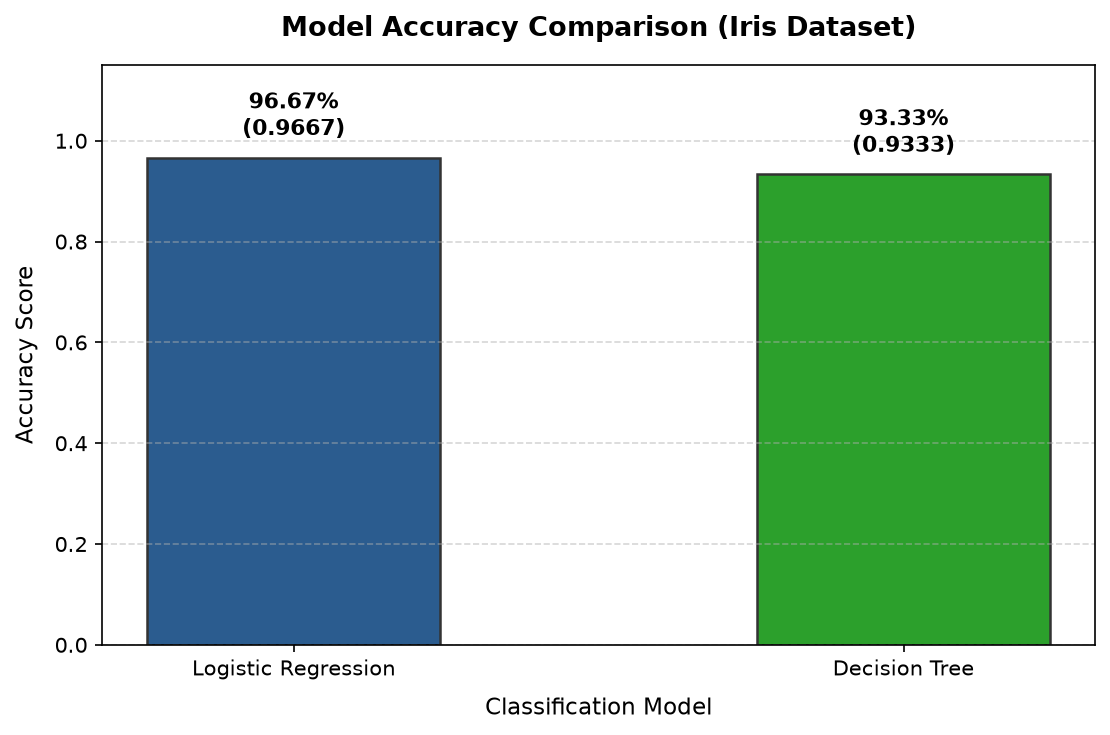

In [16]:
# Plot model accuracy comparison bar chart
plt.figure(figsize=(7.5, 5), dpi=150)
models = comparison["Model"].tolist()
accuracies = comparison["Accuracy"].tolist()

bars = plt.bar(models, accuracies, color=["#2b5c8f", "#2ca02c"], width=0.48, edgecolor="#333333", linewidth=1.2)
plt.title("Model Accuracy Comparison (Iris Dataset)", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Classification Model", fontsize=11, labelpad=8)
plt.ylabel("Accuracy Score", fontsize=11, labelpad=8)
plt.ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.03,
        f"{acc * 100:.2f}%\n({acc:.4f})",
        ha="center", va="bottom", fontsize=10.5, fontweight="bold"
    )

plt.tight_layout()
plt.show()


In [17]:
# Calculate dynamic observation values
difference = abs(logistic_accuracy - tree_accuracy)

print(f"Accuracy Difference: {difference:.4f} ({difference * 100:.2f}%)")

if logistic_accuracy > tree_accuracy:
    print("Observation: Logistic Regression achieved higher accuracy on the test set.")
elif tree_accuracy > logistic_accuracy:
    print("Observation: Decision Tree achieved higher accuracy on the test set.")
else:
    print("Observation: Both models achieved the same accuracy on the test set.")


Accuracy Difference: 0.0333 (3.33%)
Observation: Logistic Regression achieved higher accuracy on the test set.


### 18. Observations

*(Note: Statements below are based strictly on the runtime outputs of Scikit-learn)*

- **Model Comparison:** Logistic Regression achieved an accuracy of **96.67%** (29/30 correct), while Decision Tree achieved **93.33%** (28/30 correct) on the held-out test split.
- **Accuracy Difference:** Logistic Regression outperformed Decision Tree by **3.33%** (a margin of 1 sample on this 30-sample test set).
- **Linear Separability:** The Iris dataset features strong linear separability between species (particularly Setosa vs. others), which allows Logistic Regression's smooth probabilistic boundaries to generalize slightly better than Decision Tree's axis-aligned splits on this split.
- **Context Sensitivity:** Model accuracy always depends on the specific dataset, sample size, and train-test split configuration utilized.

## 19. Conclusion

Day 11 introduced the practical foundations of Supervised Classification:
1. **Classification Concepts:** Understood how classification maps numerical features to discrete class labels.
2. **Algorithm Variety:** Implemented and trained both a linear probabilistic model (**Logistic Regression**) and a rule-based model (**Decision Tree**).
3. **Fair Evaluation:** Utilized an identical stratified 80/20 train-test split for both algorithms.
4. **Objective Metrics:** Compared model performance using **Accuracy**, demonstrating how different algorithms generalize on the exact same dataset.

This project establishes a clean foundation for evaluating classification models before moving toward advanced validation and ensemble methods.